> **警告**：这个 Notebook 使用了把同一道题的多知识点 `KC(Default)` 直接展开成多个连续时间步的做法。
> 对于 AHS-KT 这类 `t -> t+1` 预测模型，这会让同一次作答的标签在相邻步之间泄露，导致指标偏高。
> 请不要再用这里的结果做汇报，改用 `run_algebra2005_ahskt_quelevel_cv_ablation.ipynb`。

# AHS-KT × Algebra 2005-2006 最小可运行 Notebook

这本 Notebook 的目标是把 `/root/autodl-tmp/ahs-kt/data/AL2005` 里的 Algebra 2005-2006 数据集接到当前仓库的 `AHSKTModel`，并完整跑通：

1. 读取 `AL2005` 原始训练日志；
2. 复用目录里已经存在的 `train_valid.csv` / `test.csv` 学生划分；
3. 从原始日志构造 AHS-KT 需要的 `.npz` bundle；
4. 生成 notebook 专用配置文件；
5. 训练 `AHSKTModel` 并在 hold-out test 上输出 `loss / auc / acc / rmse / f1`。

## 关键设计

为了让 AHS-KT 的行为特征真的有来源，本 Notebook **不直接使用** `train_valid_sequences.csv` 作为模型输入，而是从 `algebra_2005_2006_train.txt` 重建序列：

- `question_ids`：由 `Problem Name + '----' + Step Name` 映射得到；
- `concept_ids`：由 `KC(Default)` 映射得到，多 KC 行按 `~~` 展开；
- `responses`：来自 `Correct First Attempt`；
- `attempts`：由 `Incorrects + Corrects` 得到，再做 `log1p` 和 clipping；
- `hints`：来自 `Hints`，再做 `log1p` 和 clipping；
- `speed`：由 `60 / Step Duration (sec)` 得到，再做 `log1p` 和 clipping；
- `behavior_cluster`：只用 train split 的 `attempts/hints/speed` 拟合 `MiniBatchKMeans`；
- `question_difficulty` / `concept_difficulty`：只用 train split 的正确率做平滑校准，避免 valid/test 标签泄漏。

> 注意：这里使用 `train_valid.csv` 的 `fold=0` 作为 validation，其余 fold 作为 train，`test.csv` 作为 hold-out test。官方 `algebra_2005_2006_test.txt` 是无标签测试文件，不用于本 Notebook 的监督训练。

In [1]:

from pathlib import Path
import os
import sys
import json
import time
import random

PROJECT_ROOT = Path('/root/autodl-tmp/ahs-kt')
SRC_ROOT = PROJECT_ROOT / 'src'
AL2005_DIR = PROJECT_ROOT / 'data' / 'AL2005'

THREAD_ENV = {
    'OMP_NUM_THREADS': '1',
    'OPENBLAS_NUM_THREADS': '1',
    'MKL_NUM_THREADS': '1',
    'NUMEXPR_NUM_THREADS': '1',
    'VECLIB_MAXIMUM_THREADS': '1',
    'GOTO_NUM_THREADS': '1',
}
for key, value in THREAD_ENV.items():
    os.environ[key] = value

assert PROJECT_ROOT.exists(), f'找不到项目目录: {PROJECT_ROOT}'
assert AL2005_DIR.exists(), f'找不到 AL2005 数据目录: {AL2005_DIR}'
assert (AL2005_DIR / 'algebra_2005_2006_train.txt').exists(), '缺少原始训练日志 algebra_2005_2006_train.txt'
assert (AL2005_DIR / 'train_valid.csv').exists(), '缺少 train_valid.csv'
assert (AL2005_DIR / 'test.csv').exists(), '缺少 test.csv'
assert (AL2005_DIR / 'keyid2idx.json').exists(), '缺少 keyid2idx.json'

os.chdir(PROJECT_ROOT)
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('AL2005_DIR =', AL2005_DIR)
print('线程环境变量 =')
for key in THREAD_ENV:
    print(f'  {key}={os.environ[key]}')


PROJECT_ROOT = /root/autodl-tmp/ahs-kt
AL2005_DIR = /root/autodl-tmp/ahs-kt/data/AL2005
线程环境变量 =
  OMP_NUM_THREADS=1
  OPENBLAS_NUM_THREADS=1
  MKL_NUM_THREADS=1
  NUMEXPR_NUM_THREADS=1
  VECLIB_MAXIMUM_THREADS=1
  GOTO_NUM_THREADS=1


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from ahskt.config import load_config
from ahskt.data.dataset import SequenceBundle, load_bundle_from_config
from ahskt.models.ahs_kt import AHSKTModel
from ahskt.training.engine import fit_and_evaluate

print('TensorFlow version =', tf.__version__)
print('GPU devices =', tf.config.list_physical_devices('GPU'))
for gpu_device in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.unicode_minus'] = False


TensorFlow version = 2.8.0
GPU devices = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. 运行参数

这一版 Notebook 的目标不再只是“先跑通”，而是顺手得到一组更像正式实验的结果：

- `EPOCHS = 3`：比最初的 1 epoch 更稳，能看到一点收敛趋势；
- `SEED_LIST = [2024, 2025, 2026]`：做 3 个随机种子的重复实验；
- `SEQUENCE_LENGTH = 200`：与当前 AL2005 目录中的 `*_sequences.csv` 保持一致；
- `VALID_FOLD = 0`：用 5 折中的第 0 折作为 validation；
- `REMAINDER_MIN_LEN = 3`：保留长度至少为 3 的尾部短序列，因为训练会用 `t` 预测 `t+1`。

如果你后面要做更正式的实验，可以继续把：

- `EPOCHS` 调到 `5~10`；
- `SEED_LIST` 扩展到更多种子；
- `VALID_FOLD` 改成循环 5 折。


In [3]:

SEED_LIST = [2024, 2025, 2026]
FEATURE_SEED = 2026
VALID_FOLD = 0
SEQUENCE_LENGTH = 200
REMAINDER_MIN_LEN = 3
N_BEHAVIOR_CLUSTERS = 4
QUESTION_ALPHA = 5.0
CONCEPT_ALPHA = 20.0
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 0.001
PATIENCE = 2

TASK_NAME = 'ahskt_algebra2005_notebook'
FILE_PREFIX = 'algebra2005_notebook'
BASE_CONFIG_PATH = PROJECT_ROOT / 'configs' / f'{TASK_NAME}_base.json'
MULTISEED_OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'algebra2005_notebook_multiseed'
TRAIN_NPZ_PATH = PROJECT_ROOT / 'data' / f'{FILE_PREFIX}_train_ahskt.npz'
VALID_NPZ_PATH = PROJECT_ROOT / 'data' / f'{FILE_PREFIX}_valid_ahskt.npz'
TEST_NPZ_PATH = PROJECT_ROOT / 'data' / f'{FILE_PREFIX}_test_ahskt.npz'
METADATA_PATH = PROJECT_ROOT / 'data' / f'{FILE_PREFIX}_metadata.json'
RAW_RESULTS_JSON_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_raw.json'
RAW_RESULTS_CSV_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_raw.csv'
AGG_RESULTS_JSON_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_aggregate.json'
AGG_RESULTS_CSV_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_aggregate.csv'
HISTORY_JSON_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_history.json'
HISTORY_CSV_PATH = MULTISEED_OUTPUT_ROOT / f'{TASK_NAME}_history.csv'

random.seed(SEED_LIST[0])
np.random.seed(SEED_LIST[0])
tf.random.set_seed(SEED_LIST[0])

print('TASK_NAME =', TASK_NAME)
print('SEED_LIST =', SEED_LIST)
print('FEATURE_SEED =', FEATURE_SEED)
print('VALID_FOLD =', VALID_FOLD)
print('SEQUENCE_LENGTH =', SEQUENCE_LENGTH)
print('BASE_CONFIG_PATH =', BASE_CONFIG_PATH)
print('MULTISEED_OUTPUT_ROOT =', MULTISEED_OUTPUT_ROOT)


TASK_NAME = ahskt_algebra2005_notebook
SEED_LIST = [2024, 2025, 2026]
FEATURE_SEED = 2026
VALID_FOLD = 0
SEQUENCE_LENGTH = 200
BASE_CONFIG_PATH = /root/autodl-tmp/ahs-kt/configs/ahskt_algebra2005_notebook_base.json
MULTISEED_OUTPUT_ROOT = /root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed



## 2. 读取学生划分

当前 AL2005 目录已经有预处理后的 `train_valid.csv` 和 `test.csv`：

- `train_valid.csv` 中 460 个学生，`fold=0..4`；
- `test.csv` 中 114 个学生，`fold=-1`；
- 合计 574 个学生，与原始训练日志一致。

本 Notebook 使用：

- `fold != VALID_FOLD` 的学生作为 train；
- `fold == VALID_FOLD` 的学生作为 valid；
- `test.csv` 中的学生作为 test。

In [4]:

with (AL2005_DIR / 'keyid2idx.json').open('r', encoding='utf-8') as f:
    keyid2idx = json.load(f)
uid_map = {str(key): int(value) for key, value in keyid2idx['uid'].items()}

train_valid_split = pd.read_csv(AL2005_DIR / 'train_valid.csv', usecols=['fold', 'uid'])
test_split = pd.read_csv(AL2005_DIR / 'test.csv', usecols=['uid'])

train_uids = set(train_valid_split.loc[train_valid_split['fold'] != VALID_FOLD, 'uid'].astype(int))
valid_uids = set(train_valid_split.loc[train_valid_split['fold'] == VALID_FOLD, 'uid'].astype(int))
test_uids = set(test_split['uid'].astype(int))
all_split_uids = train_uids | valid_uids | test_uids

split_summary = pd.DataFrame([
    {'split': 'train', 'users': len(train_uids)},
    {'split': 'valid', 'users': len(valid_uids)},
    {'split': 'test', 'users': len(test_uids)},
    {'split': 'total', 'users': len(all_split_uids)},
])
display(split_summary)
assert len(train_uids & valid_uids) == 0
assert len(train_uids & test_uids) == 0
assert len(valid_uids & test_uids) == 0


,split,users
0,train,368
1,valid,92
2,test,114
3,total,574



## 3. 从原始日志重建 concept-level 交互

`algebra_2005_2006_train.txt` 是 tab 分隔的原始日志。这里保留有 `KC(Default)` 的行，并把多 KC 行展开成多条 concept-level 交互。

为了不丢掉少数缺时间戳的样本，序列排序使用原始 `Row` 顺序；`Row` 在 KDD Cup / DataShop 日志里本身就是稳定的原始行编号。

In [5]:

def load_raw_algebra2005() -> pd.DataFrame:
    usecols = [
        'Row',
        'Anon Student Id',
        'Problem Name',
        'Step Name',
        'Step Start Time',
        'Correct First Attempt',
        'Incorrects',
        'Hints',
        'Corrects',
        'Step Duration (sec)',
        'KC(Default)',
    ]
    raw = pd.read_csv(
        AL2005_DIR / 'algebra_2005_2006_train.txt',
        sep='	',
        usecols=usecols,
        dtype='string',
        low_memory=False,
    )
    raw['uid'] = raw['Anon Student Id'].map(uid_map)
    raw = raw[raw['uid'].notna()].copy()
    raw['uid'] = raw['uid'].astype(np.int32)
    raw = raw[raw['uid'].isin(all_split_uids)].copy()
    raw = raw[raw['KC(Default)'].notna() & (raw['KC(Default)'] != '')].copy()
    raw = raw[raw['Correct First Attempt'].isin(['0', '1'])].copy()

    raw['row_id'] = pd.to_numeric(raw['Row'], errors='coerce').fillna(0).astype(np.int64)
    raw['response'] = raw['Correct First Attempt'].astype(np.int32)
    raw['incorrects'] = pd.to_numeric(raw['Incorrects'], errors='coerce').fillna(0).clip(lower=0).astype(np.float32)
    raw['hints_raw'] = pd.to_numeric(raw['Hints'], errors='coerce').fillna(0).clip(lower=0).astype(np.float32)
    raw['corrects'] = pd.to_numeric(raw['Corrects'], errors='coerce').fillna(1).clip(lower=0).astype(np.float32)

    duration = pd.to_numeric(raw['Step Duration (sec)'], errors='coerce')
    median_duration = float(duration.dropna().median()) if duration.notna().any() else 15.0
    if not np.isfinite(median_duration) or median_duration <= 0:
        median_duration = 15.0
    raw['duration_sec'] = duration.fillna(median_duration).clip(lower=1.0).astype(np.float32)

    raw['attempt_count_raw'] = (raw['incorrects'] + raw['corrects']).clip(lower=1.0).astype(np.float32)
    raw['hint_count_raw'] = raw['hints_raw'].astype(np.float32)
    raw['speed_raw'] = (60.0 / raw['duration_sec']).astype(np.float32)
    raw['question_key'] = raw['Problem Name'].fillna('') + '----' + raw['Step Name'].fillna('')
    raw['concept_tokens'] = raw['KC(Default)'].str.split('~~')
    raw['kc_pos_list'] = raw['concept_tokens'].apply(lambda values: list(range(len(values))))
    return raw

raw_df = load_raw_algebra2005()
raw_summary = pd.DataFrame([
    {'metric': 'raw_rows_with_kc_and_label', 'value': len(raw_df)},
    {'metric': 'students', 'value': raw_df['uid'].nunique()},
    {'metric': 'question_steps_before_kc_expand', 'value': raw_df['question_key'].nunique()},
    {'metric': 'expanded_concept_interactions', 'value': int(raw_df['concept_tokens'].map(len).sum())},
    {'metric': 'mean_correct_first_attempt', 'value': raw_df['response'].mean()},
    {'metric': 'median_step_duration_sec', 'value': raw_df['duration_sec'].median()},
])
display(raw_summary)
raw_df.head(3)


,metric,value
0,raw_rows_with_kc_and_label,607025.000000
1,students,574.000000
2,question_steps_before_kc_expand,173113.000000
3,expanded_concept_interactions,884102.000000
4,mean_correct_first_attempt,0.755288
5,median_step_duration_sec,11.000000


,Row,Anon Student Id,Problem Name,Step Name,Step Start Time,Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,...,incorrects,hints_raw,corrects,duration_sec,attempt_count_raw,hint_count_raw,speed_raw,question_key,concept_tokens,kc_pos_list
0,1,0BrbPbwCMz,EG4-FIXED,3(x+2) = 15,2005-09-09 12:24:35.0,40,0,2,3,1,...,2.0,3.0,1.0,40.0,3.0,3.0,1.500000,EG4-FIXED----3(x+2) = 15,[[SkillRule: Eliminate Parens; {CLT nested; CL...,[0]
1,2,0BrbPbwCMz,EG4-FIXED,x+2 = 5,2005-09-09 12:25:15.0,16,1,0,0,1,...,0.0,0.0,1.0,16.0,1.0,0.0,3.750000,EG4-FIXED----x+2 = 5,"[[SkillRule: Remove constant; {ax+b=c, positiv...","[0, 1]"
2,3,0BrbPbwCMz,EG40,2-8y = -4,2005-09-09 12:25:36.0,36,0,2,3,1,...,2.0,3.0,1.0,36.0,3.0,3.0,1.666667,EG40----2-8y = -4,"[[SkillRule: Remove constant; {ax+b=c, positiv...",[0]


In [6]:

def expand_to_concept_level(raw: pd.DataFrame) -> pd.DataFrame:
    columns = [
        'uid',
        'question_key',
        'response',
        'attempt_count_raw',
        'hint_count_raw',
        'speed_raw',
        'duration_sec',
        'row_id',
        'concept_tokens',
        'kc_pos_list',
    ]
    expanded = (
        raw[columns]
        .explode(['concept_tokens', 'kc_pos_list'])
        .rename(columns={'concept_tokens': 'concept_key', 'kc_pos_list': 'kc_pos'})
        .copy()
    )
    expanded['kc_pos'] = expanded['kc_pos'].astype(np.int32)
    expanded['question_id'] = pd.factorize(expanded['question_key'], sort=True)[0].astype(np.int32) + 1
    expanded['concept_id'] = pd.factorize(expanded['concept_key'], sort=True)[0].astype(np.int32) + 1

    expanded['split'] = np.where(
        expanded['uid'].isin(train_uids),
        'train',
        np.where(
            expanded['uid'].isin(valid_uids),
            'valid',
            np.where(expanded['uid'].isin(test_uids), 'test', 'drop'),
        ),
    )
    expanded = expanded[expanded['split'] != 'drop'].copy()
    expanded = expanded.sort_values(['uid', 'row_id', 'kc_pos']).reset_index(drop=True)
    return expanded

expanded_df = expand_to_concept_level(raw_df)
interaction_summary = expanded_df.groupby('split').agg(
    users=('uid', 'nunique'),
    interactions=('response', 'size'),
    correct_rate=('response', 'mean'),
    unique_questions=('question_id', 'nunique'),
    unique_concepts=('concept_id', 'nunique'),
).reset_index()
interaction_summary.loc[len(interaction_summary)] = {
    'split': 'total',
    'users': expanded_df['uid'].nunique(),
    'interactions': len(expanded_df),
    'correct_rate': expanded_df['response'].mean(),
    'unique_questions': expanded_df['question_id'].nunique(),
    'unique_concepts': expanded_df['concept_id'].nunique(),
}
display(interaction_summary)
assert len(expanded_df) == 884102, f'展开后的交互数不符合预期: {len(expanded_df)}'
expanded_df.head(5)


,split,users,interactions,correct_rate,unique_questions,unique_concepts
0,test,114,135408,0.712196,35866,110
1,train,368,583274,0.718223,120119,112
2,valid,92,165420,0.702388,44072,111
3,total,574,884102,0.714337,173113,112


,uid,question_key,response,attempt_count_raw,hint_count_raw,speed_raw,duration_sec,row_id,concept_key,kc_pos,question_id,concept_id,split
0,0,EG4-FIXED----3(x+2) = 15,0,3.0,3.0,1.500000,40.0,1,[SkillRule: Eliminate Parens; {CLT nested; CLT...,0,34501,78,train
1,0,EG4-FIXED----x+2 = 5,1,1.0,0.0,3.750000,16.0,2,"[SkillRule: Remove constant; {ax+b=c, positive...",0,34507,87,train
2,0,EG4-FIXED----x+2 = 5,1,1.0,0.0,3.750000,16.0,2,"[SkillRule: Isolate positive; x+a=b, positive]",1,34507,82,train
3,0,EG40----2-8y = -4,0,3.0,3.0,1.666667,36.0,3,"[SkillRule: Remove constant; {ax+b=c, positive...",0,43861,87,train
4,0,EG40-----8y = -6,1,1.0,0.0,2.727273,22.0,4,"[SkillRule: Remove coefficient; {ax+b=c, divid...",0,41084,86,train



## 4. 构造难度与行为特征

这里有两个防泄漏原则：

1. 难度统计只用 train split 的 `response`；valid/test 里没见过的 question/concept 使用 train 全局均值作为默认值。
2. 行为聚类只用 train split 的 `attempts/hints/speed` 拟合；valid/test 只做 transform/predict。

In [7]:

def compute_smoothed_maps(frame: pd.DataFrame, id_col: str, response_col: str, alpha: float):
    grouped = frame.groupby(id_col)[response_col].agg(['sum', 'count'])
    global_mean = float(frame[response_col].mean()) if len(frame) else 0.5
    default_bin = int(np.clip(int(global_mean * 100) + 1, 1, 101))
    posterior = (grouped['sum'] + alpha * global_mean) / (grouped['count'] + alpha)
    bins = np.clip((posterior * 100).astype(int) + 1, 1, 101).astype(int)
    if alpha > 0:
        confidence = grouped['count'] / (grouped['count'] + alpha)
    else:
        confidence = pd.Series(np.ones(len(grouped), dtype=np.float32), index=grouped.index)
    return (
        bins.to_dict(),
        posterior.astype(float).to_dict(),
        confidence.astype(float).to_dict(),
        default_bin,
        global_mean,
    )


def compute_behavior_columns(frame: pd.DataFrame, clip_values=None):
    attempts_raw = frame['attempt_count_raw'].to_numpy(dtype=np.float32)
    hints_raw = frame['hint_count_raw'].to_numpy(dtype=np.float32)
    speed_raw = frame['speed_raw'].to_numpy(dtype=np.float32)

    if clip_values is None:
        clip_values = {
            'attempts': float(np.quantile(attempts_raw, 0.99)),
            'hints': float(np.quantile(hints_raw, 0.99)),
            'speed': float(np.quantile(speed_raw, 0.99)),
        }

    attempts = np.log1p(np.clip(attempts_raw, 0.0, clip_values['attempts'])).astype(np.float32)
    hints = np.log1p(np.clip(hints_raw, 0.0, clip_values['hints'])).astype(np.float32)
    speed = np.log1p(np.clip(speed_raw, 0.0, clip_values['speed'])).astype(np.float32)
    features = np.stack([attempts, hints, speed], axis=-1)
    return attempts, hints, speed, clip_values, features


def build_cluster_mapping(raw_centers: np.ndarray):
    order = sorted(
        range(len(raw_centers)),
        key=lambda idx: (
            float(raw_centers[idx, 0]),
            float(raw_centers[idx, 1]),
            float(-raw_centers[idx, 2]),
        ),
    )
    return {int(old_label): int(new_label + 1) for new_label, old_label in enumerate(order)}


def fit_behavior_clusters(train_frame: pd.DataFrame):
    _, _, _, clip_values, features = compute_behavior_columns(train_frame)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    cluster_model = MiniBatchKMeans(
        n_clusters=N_BEHAVIOR_CLUSTERS,
        random_state=FEATURE_SEED,
        n_init=20,
        batch_size=4096,
    )
    cluster_model.fit(scaled_features)
    raw_centers = scaler.inverse_transform(cluster_model.cluster_centers_)
    cluster_mapping = build_cluster_mapping(raw_centers)
    centers = []
    for old_label, center in enumerate(raw_centers):
        cluster_id = cluster_mapping[int(old_label)]
        centers.append({
            'cluster_id': int(cluster_id),
            'attempts_log_center': float(center[0]),
            'hints_log_center': float(center[1]),
            'speed_log_center': float(center[2]),
            'attempts_raw_center': float(np.expm1(center[0])),
            'hints_raw_center': float(np.expm1(center[1])),
            'speed_raw_center': float(np.expm1(center[2])),
        })
    centers = sorted(centers, key=lambda item: item['cluster_id'])
    return clip_values, scaler, cluster_model, cluster_mapping, centers


def attach_behavior_features(frame: pd.DataFrame, clip_values, scaler, cluster_model, cluster_mapping) -> pd.DataFrame:
    attempts, hints, speed, _, features = compute_behavior_columns(frame, clip_values=clip_values)
    scaled_features = scaler.transform(features)
    raw_labels = cluster_model.predict(scaled_features)
    cluster_ids = np.array([cluster_mapping[int(raw_label)] for raw_label in raw_labels], dtype=np.int32)
    enriched = frame.copy()
    enriched['attempts'] = attempts
    enriched['hints'] = hints
    enriched['speed'] = speed
    enriched['behavior_cluster'] = cluster_ids
    return enriched

train_frame_for_stats = expanded_df[expanded_df['split'] == 'train'].copy()

q_diff_map, q_ease_map, q_conf_map, default_q_diff, question_global_ease = compute_smoothed_maps(
    train_frame_for_stats,
    id_col='question_id',
    response_col='response',
    alpha=QUESTION_ALPHA,
)
c_diff_map, c_ease_map, c_conf_map, default_c_diff, concept_global_ease = compute_smoothed_maps(
    train_frame_for_stats,
    id_col='concept_id',
    response_col='response',
    alpha=CONCEPT_ALPHA,
)
clip_values, scaler, cluster_model, cluster_mapping, cluster_centers = fit_behavior_clusters(train_frame_for_stats)
expanded_df = attach_behavior_features(expanded_df, clip_values, scaler, cluster_model, cluster_mapping)

feature_summary = pd.DataFrame([
    {'metric': 'question_global_easiness', 'value': question_global_ease},
    {'metric': 'concept_global_easiness', 'value': concept_global_ease},
    {'metric': 'default_question_difficulty_bin', 'value': default_q_diff},
    {'metric': 'default_concept_difficulty_bin', 'value': default_c_diff},
    {'metric': 'num_question_difficulty_bins_seen', 'value': len(set(q_diff_map.values()))},
    {'metric': 'num_concept_difficulty_bins_seen', 'value': len(set(c_diff_map.values()))},
    {'metric': 'num_behavior_clusters_plus_padding', 'value': max(cluster_mapping.values()) + 1},
])
display(feature_summary)
display(pd.DataFrame(cluster_centers))


,metric,value
0,question_global_easiness,0.718223
1,concept_global_easiness,0.718223
2,default_question_difficulty_bin,72.000000
3,default_concept_difficulty_bin,72.000000
4,num_question_difficulty_bins_seen,98.000000
5,num_concept_difficulty_bins_seen,56.000000
6,num_behavior_clusters_plus_padding,5.000000


,cluster_id,attempts_log_center,hints_log_center,speed_log_center,attempts_raw_center,hints_raw_center,speed_raw_center
0,1,0.707558,0.003246,2.359615,1.029030,0.003251,9.586876
1,2,0.862361,1.448758,1.061368,1.368748,3.257822,1.890321
2,3,1.026651,0.003999,1.077743,1.791700,0.004007,1.938041
3,4,1.865744,1.194092,0.542464,5.460740,2.300561,0.720241



## 5. 转成 AHS-KT `.npz` bundle

当前项目的 `SequenceBundle` 需要所有字段形状一致，都是 `[num_sequences, sequence_length]`。

padding 规则：

- ID 字段的 padding 是 `0`；
- `mask=1` 表示有效位置，`mask=0` 表示 padding；
- `behavior_cluster=0` 留给 padding，真实聚类从 `1` 开始。

In [8]:

def build_sequence_bundle(
    frame: pd.DataFrame,
    split_name: str,
    sequence_length: int,
    remainder_min_len: int,
    q_diff_map: dict,
    c_diff_map: dict,
    default_q_diff: int,
    default_c_diff: int,
    q_ease_map: dict,
    c_ease_map: dict,
    q_conf_map: dict,
    c_conf_map: dict,
    default_q_ease: float,
    default_c_ease: float,
    default_confidence: float = 0.0,
) -> SequenceBundle:
    split_frame = frame[frame['split'] == split_name].copy()
    records = []

    for uid, student in split_frame.groupby('uid'):
        student = student.sort_values(['row_id', 'kc_pos'])
        payload = {
            'question_ids': student['question_id'].to_numpy(dtype=np.int32),
            'concept_ids': student['concept_id'].to_numpy(dtype=np.int32),
            'responses': student['response'].to_numpy(dtype=np.int32),
            'question_difficulty': student['question_id'].map(q_diff_map).fillna(default_q_diff).to_numpy(dtype=np.int32),
            'concept_difficulty': student['concept_id'].map(c_diff_map).fillna(default_c_diff).to_numpy(dtype=np.int32),
            'attempts': student['attempts'].to_numpy(dtype=np.float32),
            'hints': student['hints'].to_numpy(dtype=np.float32),
            'speed': student['speed'].to_numpy(dtype=np.float32),
            'behavior_cluster': student['behavior_cluster'].to_numpy(dtype=np.int32),
            'question_easiness': student['question_id'].map(q_ease_map).fillna(default_q_ease).to_numpy(dtype=np.float32),
            'concept_easiness': student['concept_id'].map(c_ease_map).fillna(default_c_ease).to_numpy(dtype=np.float32),
            'question_confidence': student['question_id'].map(q_conf_map).fillna(default_confidence).to_numpy(dtype=np.float32),
            'concept_confidence': student['concept_id'].map(c_conf_map).fillna(default_confidence).to_numpy(dtype=np.float32),
        }
        sequence_len = len(student)
        for start in range(0, sequence_len, sequence_length):
            end = min(start + sequence_length, sequence_len)
            current_len = end - start
            if current_len < max(2, remainder_min_len):
                continue
            records.append({key: value[start:end] for key, value in payload.items()})

    if not records:
        raise ValueError(f'{split_name} split 没有可用序列。')

    num_records = len(records)
    arrays = {
        'question_ids': np.zeros((num_records, sequence_length), dtype=np.int32),
        'concept_ids': np.zeros((num_records, sequence_length), dtype=np.int32),
        'responses': np.zeros((num_records, sequence_length), dtype=np.int32),
        'question_difficulty': np.zeros((num_records, sequence_length), dtype=np.int32),
        'concept_difficulty': np.zeros((num_records, sequence_length), dtype=np.int32),
        'attempts': np.zeros((num_records, sequence_length), dtype=np.float32),
        'hints': np.zeros((num_records, sequence_length), dtype=np.float32),
        'speed': np.zeros((num_records, sequence_length), dtype=np.float32),
        'behavior_cluster': np.zeros((num_records, sequence_length), dtype=np.int32),
        'mask': np.zeros((num_records, sequence_length), dtype=np.int32),
        'question_easiness': np.zeros((num_records, sequence_length), dtype=np.float32),
        'concept_easiness': np.zeros((num_records, sequence_length), dtype=np.float32),
        'question_confidence': np.zeros((num_records, sequence_length), dtype=np.float32),
        'concept_confidence': np.zeros((num_records, sequence_length), dtype=np.float32),
    }

    for row_index, record in enumerate(records):
        valid_len = len(record['question_ids'])
        for key, values in record.items():
            arrays[key][row_index, :valid_len] = values
        arrays['mask'][row_index, :valid_len] = 1

    return SequenceBundle(**arrays)


def save_bundle_npz(bundle: SequenceBundle, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(output_path, **bundle.as_dict())

train_bundle = build_sequence_bundle(
    expanded_df,
    'train',
    SEQUENCE_LENGTH,
    REMAINDER_MIN_LEN,
    q_diff_map,
    c_diff_map,
    default_q_diff,
    default_c_diff,
    q_ease_map,
    c_ease_map,
    q_conf_map,
    c_conf_map,
    question_global_ease,
    concept_global_ease,
)
valid_bundle = build_sequence_bundle(
    expanded_df,
    'valid',
    SEQUENCE_LENGTH,
    REMAINDER_MIN_LEN,
    q_diff_map,
    c_diff_map,
    default_q_diff,
    default_c_diff,
    q_ease_map,
    c_ease_map,
    q_conf_map,
    c_conf_map,
    question_global_ease,
    concept_global_ease,
)
test_bundle = build_sequence_bundle(
    expanded_df,
    'test',
    SEQUENCE_LENGTH,
    REMAINDER_MIN_LEN,
    q_diff_map,
    c_diff_map,
    default_q_diff,
    default_c_diff,
    q_ease_map,
    c_ease_map,
    q_conf_map,
    c_conf_map,
    question_global_ease,
    concept_global_ease,
)

bundle_summary = pd.DataFrame([
    {
        'split': 'train',
        'sequences': train_bundle.num_samples,
        'valid_tokens': int(train_bundle.mask.sum()),
        'sequence_length': train_bundle.sequence_length,
    },
    {
        'split': 'valid',
        'sequences': valid_bundle.num_samples,
        'valid_tokens': int(valid_bundle.mask.sum()),
        'sequence_length': valid_bundle.sequence_length,
    },
    {
        'split': 'test',
        'sequences': test_bundle.num_samples,
        'valid_tokens': int(test_bundle.mask.sum()),
        'sequence_length': test_bundle.sequence_length,
    },
])
display(bundle_summary)


,split,sequences,valid_tokens,sequence_length
0,train,3110,583272,200
1,valid,870,165420,200
2,test,732,135406,200


In [9]:

metadata = {
    'dataset_name': 'algebra2005',
    'source_dir': str(AL2005_DIR),
    'source_raw_file': str(AL2005_DIR / 'algebra_2005_2006_train.txt'),
    'split_source': {
        'train_valid_csv': str(AL2005_DIR / 'train_valid.csv'),
        'test_csv': str(AL2005_DIR / 'test.csv'),
        'valid_fold': int(VALID_FOLD),
    },
    'sequence_length': int(SEQUENCE_LENGTH),
    'remainder_min_len': int(REMAINDER_MIN_LEN),
    'num_questions': int(expanded_df['question_id'].max()),
    'num_concepts': int(expanded_df['concept_id'].max()),
    'num_question_difficulty': int(max(q_diff_map.values())),
    'num_concept_difficulty': int(max(c_diff_map.values())),
    'num_behavior_clusters': int(max(cluster_mapping.values()) + 1),
    'default_question_difficulty': int(default_q_diff),
    'default_concept_difficulty': int(default_c_diff),
    'smoothing': {
        'question_global_easiness': float(question_global_ease),
        'concept_global_easiness': float(concept_global_ease),
        'question_alpha': float(QUESTION_ALPHA),
        'concept_alpha': float(CONCEPT_ALPHA),
    },
    'behavior': {
        'n_real_clusters': int(N_BEHAVIOR_CLUSTERS),
        'clip_values': {key: float(value) for key, value in clip_values.items()},
        'cluster_centers': cluster_centers,
    },
    'split_summary': {
        'train_users': int(len(train_uids)),
        'valid_users': int(len(valid_uids)),
        'test_users': int(len(test_uids)),
        'train_sequences': int(train_bundle.num_samples),
        'valid_sequences': int(valid_bundle.num_samples),
        'test_sequences': int(test_bundle.num_samples),
        'train_interactions': int(train_bundle.mask.sum()),
        'valid_interactions': int(valid_bundle.mask.sum()),
        'test_interactions': int(test_bundle.mask.sum()),
        'total_interactions': int(train_bundle.mask.sum() + valid_bundle.mask.sum() + test_bundle.mask.sum()),
    },
}

save_bundle_npz(train_bundle, TRAIN_NPZ_PATH)
save_bundle_npz(valid_bundle, VALID_NPZ_PATH)
save_bundle_npz(test_bundle, TEST_NPZ_PATH)
METADATA_PATH.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('saved train npz:', TRAIN_NPZ_PATH)
print('saved valid npz:', VALID_NPZ_PATH)
print('saved test npz:', TEST_NPZ_PATH)
print('saved metadata:', METADATA_PATH)
print(json.dumps(metadata['split_summary'], ensure_ascii=False, indent=2))


saved train npz: /root/autodl-tmp/ahs-kt/data/algebra2005_notebook_train_ahskt.npz
saved valid npz: /root/autodl-tmp/ahs-kt/data/algebra2005_notebook_valid_ahskt.npz
saved test npz: /root/autodl-tmp/ahs-kt/data/algebra2005_notebook_test_ahskt.npz
saved metadata: /root/autodl-tmp/ahs-kt/data/algebra2005_notebook_metadata.json
{
  "train_users": 368,
  "valid_users": 92,
  "test_users": 114,
  "train_sequences": 3110,
  "valid_sequences": 870,
  "test_sequences": 732,
  "train_interactions": 583272,
  "valid_interactions": 165420,
  "test_interactions": 135406,
  "total_interactions": 884098
}



## 6. 生成基础训练配置模板

这里先写一个 **基础配置模板**，然后在多 seed 训练时按种子复制出：

- 不同的 `seed`
- 不同的 `task_name`
- 不同的 `outputs.root_dir`

模型结构沿用当前仓库中较稳定的 `assist2009_v5` 风格：

- `fusion_mode = late_residual`
- `use_target_interaction = True`
- `difficulty_mode = smoothed_target_calibration`
- `difficulty_feature_source = question_only`


In [10]:

base_config_payload = {
    'project_name': 'ahs-kt',
    'task_name': TASK_NAME,
    'seed': int(SEED_LIST[0]),
    'dataset': {
        'mode': 'real_npz',
        'train_path': str(TRAIN_NPZ_PATH.relative_to(PROJECT_ROOT)),
        'valid_path': str(VALID_NPZ_PATH.relative_to(PROJECT_ROOT)),
        'test_path': str(TEST_NPZ_PATH.relative_to(PROJECT_ROOT)),
    },
    'model': {
        'num_questions': int(metadata['num_questions']),
        'num_concepts': int(metadata['num_concepts']),
        'num_question_difficulty': int(metadata['num_question_difficulty']),
        'num_concept_difficulty': int(metadata['num_concept_difficulty']),
        'num_behavior_clusters': int(metadata['num_behavior_clusters']),
        'sequence_length': int(metadata['sequence_length']),
        'embedding_dim': 64,
        'difficulty_dim': 32,
        'behavior_dim': 32,
        'hidden_dim': 96,
        'dropout': 0.2,
        'use_behavior_cluster': True,
        'use_difficulty_features': True,
        'use_behavior_features': True,
        'use_target_interaction': True,
        'question_global_easiness': float(metadata['smoothing']['question_global_easiness']),
        'concept_global_easiness': float(metadata['smoothing']['concept_global_easiness']),
        'fusion_mode': 'late_residual',
        'behavior_condition_on_difficulty': False,
        'aux_residual_scale': 0.1,
        'difficulty_mode': 'smoothed_target_calibration',
        'difficulty_bias_scale': 0.05,
        'difficulty_feature_source': 'question_only',
    },
    'training': {
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'learning_rate': float(LEARNING_RATE),
        'patience': int(PATIENCE),
    },
    'demo': {
        'train_size': 0,
        'valid_size': 0,
        'test_size': 0,
    },
    'outputs': {
        'root_dir': str((MULTISEED_OUTPUT_ROOT / 'base').relative_to(PROJECT_ROOT)),
    },
}

BASE_CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
BASE_CONFIG_PATH.write_text(json.dumps(base_config_payload, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved base config:', BASE_CONFIG_PATH)
print(json.dumps(base_config_payload, ensure_ascii=False, indent=2))


saved base config: /root/autodl-tmp/ahs-kt/configs/ahskt_algebra2005_notebook_base.json
{
  "project_name": "ahs-kt",
  "task_name": "ahskt_algebra2005_notebook",
  "seed": 2024,
  "dataset": {
    "mode": "real_npz",
    "train_path": "data/algebra2005_notebook_train_ahskt.npz",
    "valid_path": "data/algebra2005_notebook_valid_ahskt.npz",
    "test_path": "data/algebra2005_notebook_test_ahskt.npz"
  },
  "model": {
    "num_questions": 173113,
    "num_concepts": 112,
    "num_question_difficulty": 100,
    "num_concept_difficulty": 100,
    "num_behavior_clusters": 5,
    "sequence_length": 200,
    "embedding_dim": 64,
    "difficulty_dim": 32,
    "behavior_dim": 32,
    "hidden_dim": 96,
    "dropout": 0.2,
    "use_behavior_cluster": true,
    "use_difficulty_features": true,
    "use_behavior_features": true,
    "use_target_interaction": true,
    "question_global_easiness": 0.7182233392882248,
    "concept_global_easiness": 0.7182233392882248,
    "fusion_mode": "late_residu


## 7. 加载 bundle 并检查形状

这一步仍然只做一次：

- 用基础配置加载 `.npz` bundle；
- 后面的多 seed 实验共享同一份 train / valid / test bundle；
- 不同 seed 只影响模型初始化、batch shuffle 和训练轨迹，不影响数据切分本身。


In [11]:

base_config = load_config(BASE_CONFIG_PATH, project_root=PROJECT_ROOT)
train_bundle, valid_bundle, test_bundle = load_bundle_from_config(base_config)

print('train / valid / test 序列数 =', train_bundle.num_samples, valid_bundle.num_samples, test_bundle.num_samples)
print('sequence_length =', train_bundle.sequence_length)
print('train bundle shapes:')
for key, value in train_bundle.as_dict().items():
    print(f'  {key}: {value.shape}, dtype={value.dtype}')


train / valid / test 序列数 = 3110 870 732
sequence_length = 200
train bundle shapes:
  question_ids: (3110, 200), dtype=int32
  concept_ids: (3110, 200), dtype=int32
  responses: (3110, 200), dtype=int32
  question_difficulty: (3110, 200), dtype=int32
  concept_difficulty: (3110, 200), dtype=int32
  attempts: (3110, 200), dtype=float32
  hints: (3110, 200), dtype=float32
  speed: (3110, 200), dtype=float32
  behavior_cluster: (3110, 200), dtype=int32
  mask: (3110, 200), dtype=int32
  question_easiness: (3110, 200), dtype=float32
  concept_easiness: (3110, 200), dtype=float32
  question_confidence: (3110, 200), dtype=float32
  concept_confidence: (3110, 200), dtype=float32



## 8. 多 seed 训练 AHS-KT

下面会对 `SEED_LIST` 中的每个 seed 分别执行：

1. 生成该 seed 的独立配置文件；
2. 建立独立输出目录与 checkpoint；
3. 训练 `AHSKTModel`；
4. 计算 test `loss / auc / acc / rmse / f1`；
5. 保存单 seed 的 metrics JSON。

最后再把所有 seed 的结果汇总成表格和 CSV / JSON。

In [12]:

def build_seed_config_payload(base_payload: dict, seed: int) -> dict:
    payload = json.loads(json.dumps(base_payload))
    payload['seed'] = int(seed)
    payload['task_name'] = f'{TASK_NAME}_seed{seed}'
    payload['outputs']['root_dir'] = str((MULTISEED_OUTPUT_ROOT / f'seed_{seed}').relative_to(PROJECT_ROOT))
    return payload


def collect_targets_and_predictions(model, bundle, batch_size):
    dataset = bundle.to_tf_dataset(batch_size=batch_size, shuffle=False)
    all_targets = []
    all_predictions = []
    for batch in dataset:
        logits = model(batch, training=False)
        next_logits = logits[:, :-1]
        next_targets = tf.cast(batch['responses'][:, 1:], tf.float32)
        next_mask = tf.cast(batch['mask'][:, 1:], tf.float32)
        valid_logits = tf.boolean_mask(next_logits, next_mask > 0)
        valid_targets = tf.boolean_mask(next_targets, next_mask > 0)
        all_targets.append(valid_targets.numpy())
        all_predictions.append(tf.sigmoid(valid_logits).numpy())
    return np.concatenate(all_targets, axis=0), np.concatenate(all_predictions, axis=0)


all_seed_results = []
all_history_rows = []
seed_config_paths = []

for seed in SEED_LIST:
    print(f'===== 开始训练 seed={seed} =====')
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    seed_config_payload = build_seed_config_payload(base_config_payload, seed)
    seed_config_path = PROJECT_ROOT / 'configs' / f'{TASK_NAME}_seed{seed}.json'
    seed_config_path.write_text(json.dumps(seed_config_payload, ensure_ascii=False, indent=2), encoding='utf-8')
    seed_config_paths.append(seed_config_path)

    seed_config = load_config(seed_config_path, project_root=PROJECT_ROOT)
    model = AHSKTModel(seed_config.model)

    train_start = time.time()
    metrics_summary = fit_and_evaluate(
        model=model,
        train_bundle=train_bundle,
        valid_bundle=valid_bundle,
        test_bundle=test_bundle,
        config=seed_config,
    )
    train_elapsed = time.time() - train_start

    metrics_path = seed_config.output_root / f'{seed_config.task_name}_metrics.json'
    metrics_path.write_text(json.dumps(metrics_summary, ensure_ascii=False, indent=2), encoding='utf-8')

    test_targets, test_predictions = collect_targets_and_predictions(
        model=model,
        bundle=test_bundle,
        batch_size=seed_config.training.batch_size,
    )
    test_binary_predictions = (test_predictions > 0.5).astype(int)
    summary_with_f1 = {
        'acc': float(accuracy_score(test_targets, test_binary_predictions)),
        'auc': float(roc_auc_score(test_targets, test_predictions)),
        'f1': float(f1_score(test_targets, test_binary_predictions)),
        'loss': float(metrics_summary['test_metrics']['loss']),
        'rmse': float(metrics_summary['test_metrics']['rmse']),
        'num_test_points': int(len(test_targets)),
        'best_epoch': int(metrics_summary['best_epoch']),
        'checkpoint_path': metrics_summary['checkpoint_path'],
    }
    summary_with_f1_path = seed_config.output_root / f'{seed_config.task_name}_metrics_with_f1.json'
    summary_with_f1_path.write_text(json.dumps(summary_with_f1, ensure_ascii=False, indent=2), encoding='utf-8')

    all_seed_results.append({
        'seed': int(seed),
        'epochs': int(seed_config.training.epochs),
        'batch_size': int(seed_config.training.batch_size),
        'best_epoch': int(metrics_summary['best_epoch']),
        'best_valid_auc': float(metrics_summary['best_valid_auc']),
        'test_loss': float(metrics_summary['test_metrics']['loss']),
        'test_auc': float(metrics_summary['test_metrics']['auc']),
        'test_acc': float(metrics_summary['test_metrics']['acc']),
        'test_rmse': float(metrics_summary['test_metrics']['rmse']),
        'test_f1': float(summary_with_f1['f1']),
        'num_test_points': int(summary_with_f1['num_test_points']),
        'train_seconds': float(train_elapsed),
        'config_path': str(seed_config_path),
        'metrics_path': str(metrics_path),
        'metrics_with_f1_path': str(summary_with_f1_path),
        'checkpoint_path': str(metrics_summary['checkpoint_path']),
    })

    for item in metrics_summary['history']:
        for split in ['train', 'valid']:
            row = {'seed': int(seed), 'epoch': int(item['epoch']), 'split': split}
            row.update({key: float(value) for key, value in item[split].items()})
            all_history_rows.append(row)

    print(json.dumps(all_seed_results[-1], ensure_ascii=False, indent=2))

results_df = pd.DataFrame(all_seed_results).sort_values('seed').reset_index(drop=True)
history_df = pd.DataFrame(all_history_rows).sort_values(['seed', 'epoch', 'split']).reset_index(drop=True)

display(results_df)


===== 开始训练 seed=2024 =====


2026-04-13 19:49:40.354756: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 19:49:40.911344: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:d6:00.0, compute capability: 8.6


2026-04-13 19:49:41.677940: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


2026-04-13 19:49:42.193801: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8200


{
  "seed": 2024,
  "epochs": 3,
  "batch_size": 16,
  "best_epoch": 1,
  "best_valid_auc": 0.919434762213347,
  "test_loss": 0.2953060567378998,
  "test_auc": 0.9217818800549541,
  "test_acc": 0.8683636039621605,
  "test_rmse": 0.3054025173187256,
  "test_f1": 0.9106784767778148,
  "num_test_points": 134674,
  "train_seconds": 39.8954017162323,
  "config_path": "/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2005_notebook_seed2024.json",
  "metrics_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2024/ahskt_algebra2005_notebook_seed2024_metrics.json",
  "metrics_with_f1_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2024/ahskt_algebra2005_notebook_seed2024_metrics_with_f1.json",
  "checkpoint_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2024/checkpoints/ckpt-1"
}
===== 开始训练 seed=2025 =====


{
  "seed": 2025,
  "epochs": 3,
  "batch_size": 16,
  "best_epoch": 1,
  "best_valid_auc": 0.9196901488260205,
  "test_loss": 0.29490774869918823,
  "test_auc": 0.9222237833359419,
  "test_acc": 0.8690244590641104,
  "test_rmse": 0.3051307201385498,
  "test_f1": 0.9111604692040756,
  "num_test_points": 134674,
  "train_seconds": 38.60933065414429,
  "config_path": "/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2005_notebook_seed2025.json",
  "metrics_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2025/ahskt_algebra2005_notebook_seed2025_metrics.json",
  "metrics_with_f1_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2025/ahskt_algebra2005_notebook_seed2025_metrics_with_f1.json",
  "checkpoint_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2025/checkpoints/ckpt-1"
}
===== 开始训练 seed=2026 =====


{
  "seed": 2026,
  "epochs": 3,
  "batch_size": 16,
  "best_epoch": 1,
  "best_valid_auc": 0.9196670556386314,
  "test_loss": 0.29347965121269226,
  "test_auc": 0.9223463077582967,
  "test_acc": 0.8708807936201494,
  "test_rmse": 0.3040138781070709,
  "test_f1": 0.9134664669496544,
  "num_test_points": 134674,
  "train_seconds": 38.66112947463989,
  "config_path": "/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2005_notebook_seed2026.json",
  "metrics_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2026/ahskt_algebra2005_notebook_seed2026_metrics.json",
  "metrics_with_f1_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2026/ahskt_algebra2005_notebook_seed2026_metrics_with_f1.json",
  "checkpoint_path": "/root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/seed_2026/checkpoints/ckpt-1"
}


,seed,epochs,batch_size,best_epoch,best_valid_auc,test_loss,test_auc,test_acc,test_rmse,test_f1,num_test_points,train_seconds,config_path,metrics_path,metrics_with_f1_path,checkpoint_path
0,2024,3,16,1,0.919435,0.295306,0.921782,0.868364,0.305403,0.910678,134674,39.895402,/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...
1,2025,3,16,1,0.919690,0.294908,0.922224,0.869024,0.305131,0.911160,134674,38.609331,/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...
2,2026,3,16,1,0.919667,0.293480,0.922346,0.870881,0.304014,0.913466,134674,38.661129,/root/autodl-tmp/ahs-kt/configs/ahskt_algebra2...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...,/root/autodl-tmp/ahs-kt/outputs/algebra2005_no...



## 9. 结果汇总表、导出文件与可视化

这一节会输出三类结果：

- **raw results**：每个 seed 一行；
- **aggregate summary**：对 `auc / acc / f1 / loss / rmse / train_seconds` 做均值、标准差、最小值、最大值；
- **history**：每个 seed、每个 epoch、每个 split 的训练轨迹。

同时会把这些结果导出成 CSV / JSON，方便你后续写论文表格或继续分析。

In [13]:

aggregate_metrics = ['best_valid_auc', 'test_auc', 'test_acc', 'test_f1', 'test_loss', 'test_rmse', 'train_seconds']
aggregate_df = pd.DataFrame([
    {
        'metric': metric,
        'mean': float(results_df[metric].mean()),
        'std': float(results_df[metric].std(ddof=0)),
        'min': float(results_df[metric].min()),
        'max': float(results_df[metric].max()),
    }
    for metric in aggregate_metrics
])

MULTISEED_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RAW_RESULTS_JSON_PATH.write_text(json.dumps(results_df.to_dict(orient='records'), ensure_ascii=False, indent=2), encoding='utf-8')
RAW_RESULTS_CSV_PATH.write_text(results_df.to_csv(index=False), encoding='utf-8')
AGG_RESULTS_JSON_PATH.write_text(json.dumps(aggregate_df.to_dict(orient='records'), ensure_ascii=False, indent=2), encoding='utf-8')
AGG_RESULTS_CSV_PATH.write_text(aggregate_df.to_csv(index=False), encoding='utf-8')
HISTORY_JSON_PATH.write_text(json.dumps(history_df.to_dict(orient='records'), ensure_ascii=False, indent=2), encoding='utf-8')
HISTORY_CSV_PATH.write_text(history_df.to_csv(index=False), encoding='utf-8')

print('saved raw results to', RAW_RESULTS_JSON_PATH)
print('saved aggregate results to', AGG_RESULTS_JSON_PATH)
print('saved history to', HISTORY_JSON_PATH)

display(
    results_df.style.format({
        'best_valid_auc': '{:.4f}',
        'test_loss': '{:.4f}',
        'test_auc': '{:.4f}',
        'test_acc': '{:.4f}',
        'test_rmse': '{:.4f}',
        'test_f1': '{:.4f}',
        'train_seconds': '{:.2f}',
    }).background_gradient(subset=['best_valid_auc', 'test_auc', 'test_acc', 'test_f1'], cmap='YlGn')
)

display(
    aggregate_df.style.format({
        'mean': '{:.4f}',
        'std': '{:.4f}',
        'min': '{:.4f}',
        'max': '{:.4f}',
    }).background_gradient(subset=['mean'], cmap='Blues')
)


saved raw results to /root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_raw.json
saved aggregate results to /root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_aggregate.json
saved history to /root/autodl-tmp/ahs-kt/outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_history.json


AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

AttributeError: 'ColormapRegistry' object has no attribute 'get_cmap'

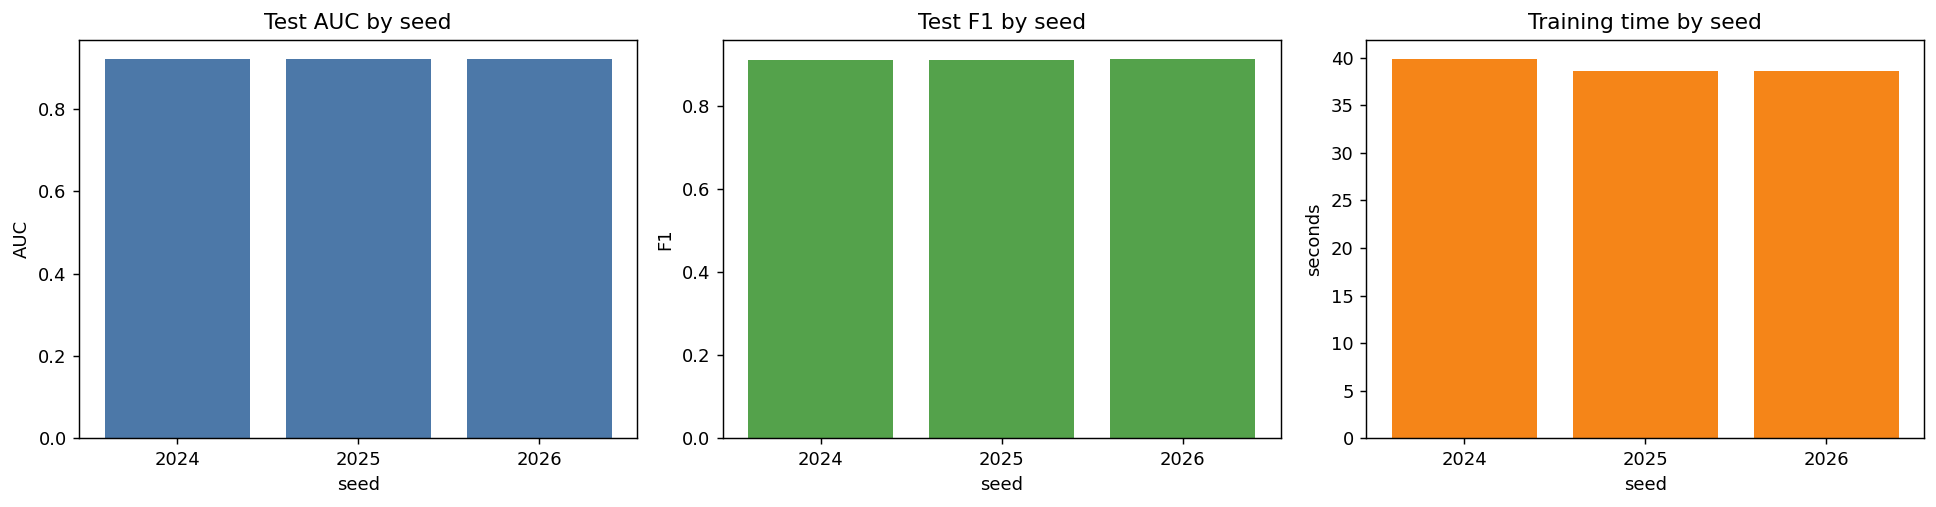

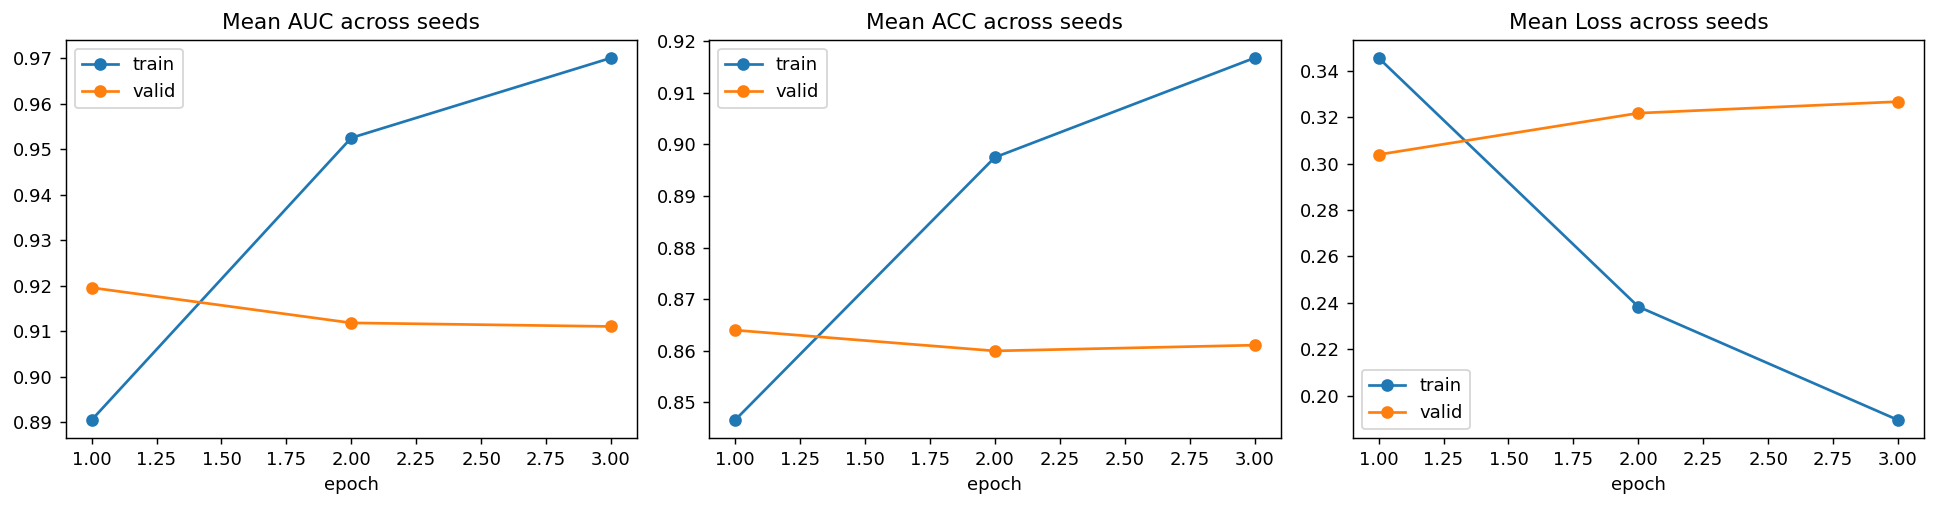

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(results_df['seed'].astype(str), results_df['test_auc'], color='#4c78a8')
axes[0].set_title('Test AUC by seed')
axes[0].set_xlabel('seed')
axes[0].set_ylabel('AUC')

axes[1].bar(results_df['seed'].astype(str), results_df['test_f1'], color='#54a24b')
axes[1].set_title('Test F1 by seed')
axes[1].set_xlabel('seed')
axes[1].set_ylabel('F1')

axes[2].bar(results_df['seed'].astype(str), results_df['train_seconds'], color='#f58518')
axes[2].set_title('Training time by seed')
axes[2].set_xlabel('seed')
axes[2].set_ylabel('seconds')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for split, group in history_df.groupby('split'):
    mean_curve = group.groupby('epoch')[['auc', 'acc', 'loss']].mean().reset_index()
    axes[0].plot(mean_curve['epoch'].to_numpy(), mean_curve['auc'].to_numpy(), marker='o', label=split)
    axes[1].plot(mean_curve['epoch'].to_numpy(), mean_curve['acc'].to_numpy(), marker='o', label=split)
    axes[2].plot(mean_curve['epoch'].to_numpy(), mean_curve['loss'].to_numpy(), marker='o', label=split)
axes[0].set_title('Mean AUC across seeds')
axes[1].set_title('Mean ACC across seeds')
axes[2].set_title('Mean Loss across seeds')
for ax in axes:
    ax.set_xlabel('epoch')
    ax.legend()
plt.tight_layout()
plt.show()



## 10. 结论与下一步

如果上面的单元全部执行成功，说明这本 Notebook 已经不只是“跑通”版本，而是一个**可直接做小规模正式实验**的版本。它会产出：

- `data/algebra2005_notebook_train_ahskt.npz`
- `data/algebra2005_notebook_valid_ahskt.npz`
- `data/algebra2005_notebook_test_ahskt.npz`
- `data/algebra2005_notebook_metadata.json`
- `configs/ahskt_algebra2005_notebook_base.json`
- `configs/ahskt_algebra2005_notebook_seed2024.json` 等每个 seed 的配置
- `outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_raw.csv`
- `outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_aggregate.csv`
- `outputs/algebra2005_notebook_multiseed/ahskt_algebra2005_notebook_history.csv`
- 以及每个 seed 各自的 metrics / metrics_with_f1 / checkpoint

如果你下一步想继续往“论文实验”靠近，最有价值的扩展通常是：

1. 循环 `VALID_FOLD=0..4` 做 5 折；
2. 加上 ablation：`difficulty only`、`behavior only`、`full model`；
3. 固定同一套 seed，和其他 KT baseline 做公平对比；
4. 用汇总表直接生成论文里的主表和附录表。
